In [101]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, html, dcc

In [2]:
#Show all columns when displaying DataFrames.
pd.set_option("display.max_columns", None) 

In [3]:
import os
os.listdir("Predictive E-Commerce Intelligence Platform")

['.ipynb_checkpoints',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [4]:
customers = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_customers_dataset.csv"
)

orders = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_order_reviews_dataset.csv"
)

products = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_products_dataset.csv"
)

sellers = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/olist_sellers_dataset.csv"
)

category_translation = pd.read_csv(
    "Predictive E-Commerce Intelligence Platform/product_category_name_translation.csv"
)

In [5]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [6]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
customers.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [8]:
customers["customer_id"].nunique()    

99441

In [9]:
customers["customer_unique_id"].nunique()     

96096

In [10]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

# Customer Table Findings

- Customer table contains 99,441 records.
- No missing values detected.
- customer_id is unique and can be treated as the primary key.
- customer_unique_id contains 96,096 unique values, indicating repeat customers.
- Sao Paulo (SP) has the highest customer concentration with 41,746 customers.

In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])

orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])

orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [15]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [16]:
orders[orders["order_status"] == "canceled"].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaT,2018-02-23
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17


In [17]:
orders["order_id"].nunique()


99441

In [18]:
orders["customer_id"].nunique()

99441

## Orders Table Findings

- Orders table contains 99,441 records.
- order_id is unique and serves as the primary key.
- customer_id is unique within the orders table.
- Missing delivery-related dates are associated with non-delivered orders and represent business events rather than data quality issues.
- The Orders table acts as the central transaction table connecting customers, payments, reviews, and order items.

In [19]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [21]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"] )

In [22]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [23]:
order_items["order_id"].nunique()

98666

In [24]:
order_items["product_id"].nunique()

32951

In [25]:
order_items.groupby("order_id").size().sort_values(ascending = False).head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
c05d6a79e55da72ca780ce90364abed9    12
dtype: int64

In [26]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [27]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [28]:
products["product_id"].nunique()

32951

In [29]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

## Products Table Findings

- Product table contains 32,951 products.
- product_id contains no missing values.
- 610 products (1.85%) have missing category and description-related attributes.
- Only 2 products have missing physical dimensions.
- Overall data quality is high, with missing values concentrated in product metadata.

In [30]:
products[products["product_category_name"].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [31]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [32]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [33]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

## Payments Table Findings

- Payments table contains 103,886 records.
- No missing values detected.
- Credit cards account for the majority of payments (~74%).
- Installment information is available and can be used for customer spending analysis.
- The number of payment records exceeds the number of orders, indicating that some orders contain multiple payment transactions.

In [34]:
payments["order_id"].nunique()

99440

In [35]:
payments.groupby("order_id").size().sort_values(ascending=False).head(10)

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
ee9ca989fc93ba09a6eddc250ce01742    19
4bfcba9e084f46c8e3cb49b0fa6e6159    15
21577126c19bf11a0b91592e5844ba78    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
dtype: int64

In [36]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [37]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [38]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])

reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [39]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [40]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

## Reviews Table Findings

- Reviews table contains 99,224 records.
- Review date columns were converted to datetime.
- Review comments are optional and contain many null values.
- Approximately 77% of reviews are rated 4 or 5 stars.
- 5-star reviews are the most common rating.
- Customer satisfaction appears generally high.

In [41]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [42]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [43]:
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

## Sellers Table Findings

- Sellers table contains 3,095 sellers.
- Seller distribution is heavily concentrated in São Paulo (SP).
- Approximately 60% of all sellers are located in SP.
- The seller distribution pattern is similar to the customer distribution pattern.

In [44]:
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [45]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [46]:
(customers.isnull().sum())
(orders.isnull().sum())
(order_items.isnull().sum())
(payments.isnull().sum())
(reviews.isnull().sum())
(products.isnull().sum())
(sellers.isnull().sum())

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [47]:
print("Customers:", customers.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Order Items:", order_items.duplicated().sum())
print("Payments:", payments.duplicated().sum())
print("Reviews:", reviews.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Sellers:", sellers.duplicated().sum())

Customers: 0
Orders: 0
Order Items: 0
Payments: 0
Reviews: 0
Products: 0
Sellers: 0


In [48]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [49]:
orders["delivery_days"] = (orders["order_delivered_customer_date"] - 
                           orders["order_purchase_timestamp"]).dt.days 

In [50]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [51]:
orders.sort_values(by = "delivery_days", ascending = False) [["order_id", "order_status","delivery_days"]].head(10)

,order_id,order_status,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,208.0
61610,440d0d17af552815d15a9e41abe49359,delivered,195.0
89130,285ab9426d6982034523a855f55a885e,delivered,194.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,194.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,194.0
11399,47b40429ed8cce3aee9199792275433f,delivered,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,188.0
62286,437222e3fd1b07396f1d9ba8c15fba59,delivered,187.0


In [52]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [53]:
orders.sort_values(
    by="delivery_days",
    ascending=False
)[[
    "order_id",
    "order_status",
    "delivery_days",
    "delivery_delay_days",
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "order_delivered_customer_date"
]].head(10)

,order_id,order_status,delivery_days,delivery_delay_days,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date
19590,ca07593549f1816d26a572e06dc1eab6,delivered,209.0,181.0,2017-02-21 23:31:27,2017-03-22,2017-09-19 14:36:39
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,208.0,188.0,2018-02-23 14:57:35,2018-03-15,2018-09-19 23:24:07
61610,440d0d17af552815d15a9e41abe49359,delivered,195.0,165.0,2017-03-07 23:59:51,2017-04-07,2017-09-19 15:12:50
89130,285ab9426d6982034523a855f55a885e,delivered,194.0,166.0,2017-03-08 22:47:40,2017-04-06,2017-09-19 14:00:04
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,194.0,155.0,2017-03-08 18:09:02,2017-04-17,2017-09-19 14:33:17
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,194.0,161.0,2017-03-09 13:26:57,2017-04-11,2017-09-19 14:38:21
11399,47b40429ed8cce3aee9199792275433f,delivered,191.0,175.0,2018-01-03 09:44:01,2018-01-19,2018-07-13 20:51:31
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,189.0,167.0,2017-03-13 20:17:10,2017-04-05,2017-09-19 17:00:07
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,188.0,159.0,2017-03-15 11:24:27,2017-04-13,2017-09-19 14:38:18
62286,437222e3fd1b07396f1d9ba8c15fba59,delivered,187.0,144.0,2017-03-16 11:36:00,2017-04-28,2017-09-19 16:28:58


In [54]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

In [55]:
orders["order_year"] = orders["order_purchase_timestamp"].dt.year

orders["order_month"] = orders["order_purchase_timestamp"].dt.month

orders["order_day"] = orders["order_purchase_timestamp"].dt.day

orders["order_weekday"] = orders["order_purchase_timestamp"].dt.day_name()

In [56]:
orders[[
    "order_purchase_timestamp",
    "order_year",
    "order_month",
    "order_day",
    "order_weekday"
]].head()

,order_purchase_timestamp,order_year,order_month,order_day,order_weekday
0,2017-10-02 10:56:33,2017,10,2,Monday
1,2018-07-24 20:41:37,2018,7,24,Tuesday
2,2018-08-08 08:38:49,2018,8,8,Wednesday
3,2017-11-18 19:28:06,2017,11,18,Saturday
4,2018-02-13 21:18:39,2018,2,13,Tuesday


In [57]:
order_items["total_item_value"] = (
    order_items["price"] +
    order_items["freight_value"]
)

In [58]:
#Revenue
order_items[[
    "price",
    "freight_value",
    "total_item_value"
]].head()

,price,freight_value,total_item_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [59]:
#shipping percentage
order_items["shipping_pct"] = (
    order_items["freight_value"]
    / order_items["total_item_value"]
) * 100

In [60]:
order_items["total_item_value"].describe()

count    112650.000000
mean        140.644059
std         190.724394
min           6.080000
25%          55.220000
50%          92.320000
75%         157.937500
max        6929.310000
Name: total_item_value, dtype: float64

In [61]:
order_items.sort_values(
    by="total_item_value",
    ascending=False
)[[
    "order_id",
    "product_id",
    "seller_id",
    "price",
    "freight_value",
    "total_item_value"
]].head(10)

,order_id,product_id,seller_id,price,freight_value,total_item_value
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,6735.00,194.31,6929.31
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,6729.00,193.21,6922.21
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,6499.00,227.66,6726.66
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,4799.00,151.34,4950.34
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,4690.00,74.34,4764.34
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,4590.00,91.78,4681.78
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,4399.87,113.45,4513.32
56663,80dfedb6d17bf23539beeef3c768f4d7,4ca7b91a31637bd24fb8e559d5e015e4,59417c56835dd8e2e72f91f809cd4092,3999.00,195.76,4194.76
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,4099.99,75.27,4175.26
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,4059.00,104.51,4163.51


## Revenue Feature Findings

- Average item value is 140.64.
- Median item value is 92.32.
- Revenue distribution is positively skewed.
- High-value transactions exist, with the maximum item value reaching 6,929.31.
- Outlier investigation is required for premium transactions.

In [62]:
order_items["total_item_value"].sum()

np.float64(15843553.24)

In [63]:
#Order-Level Revenue
order_revenue = (
    order_items
    .groupby("order_id")["total_item_value"]
    .sum()
    .reset_index()
)

order_revenue.head()

,order_id,total_item_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [64]:
order_revenue["total_item_value"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: total_item_value, dtype: float64

In [65]:
#Average Order Value (AOV)
order_revenue = (
    order_items.groupby("order_id")
    ["total_item_value"].sum().reset_index()
)

order_revenue.head()

,order_id,total_item_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [66]:
order_revenue["total_item_value"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: total_item_value, dtype: float64

In [67]:
#Monthly Revenue Trend

monthly_revenue = (
    order_items.merge(orders[["order_id", "order_purchase_timestamp"]],
                     on = "order_id",
                     how = "left")  
)

monthly_revenue["year_month"] = (
    monthly_revenue["order_purchase_timestamp"].dt.to_period("M")
)

monthly_revenue = (
    monthly_revenue
    .groupby("year_month")["total_item_value"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,year_month,total_item_value
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62


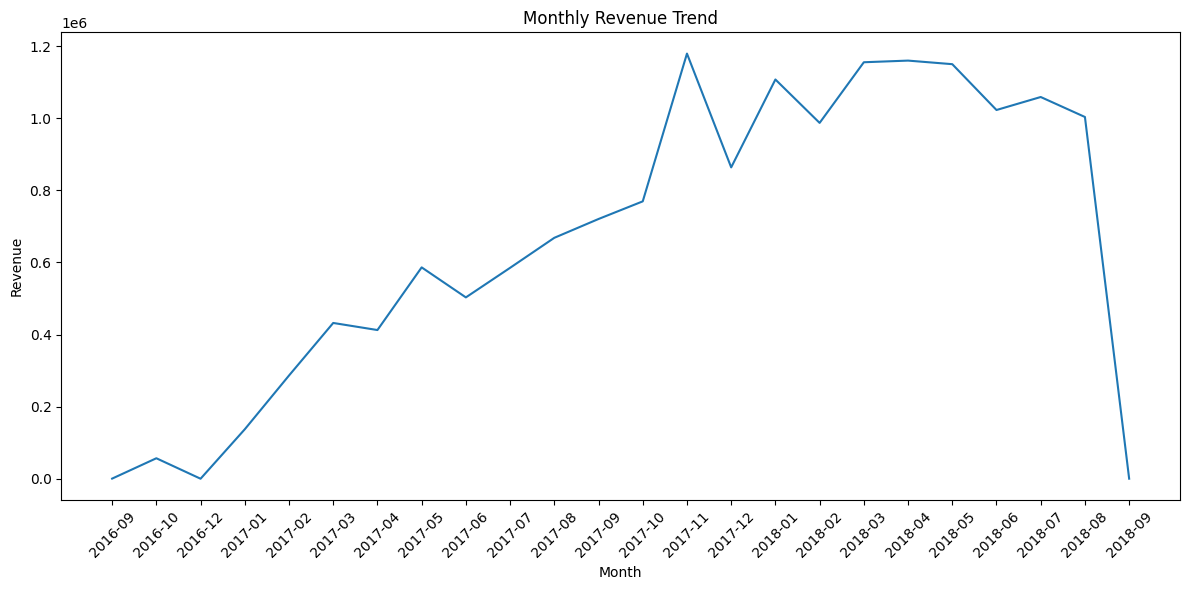

In [68]:
plt.figure(figsize = (12,6))

plt.plot(
    monthly_revenue["year_month"].astype(str),
    monthly_revenue["total_item_value"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()

plt.show()

In [69]:
#Top Revenue Months
monthly_revenue.sort_values(
    by="total_item_value",
    ascending=False
).head(10)

,year_month,total_item_value
13,2017-11,1179143.77
18,2018-04,1159698.04
17,2018-03,1155126.82
19,2018-05,1149781.82
15,2018-01,1107301.89
21,2018-07,1058728.03
20,2018-06,1022677.11
22,2018-08,1003308.47
16,2018-02,986908.96
14,2017-12,863547.23


In [70]:
# Monthly Order Trend
monthly_orders = (
    orders.groupby(orders["order_purchase_timestamp"].dt.to_period("M"))
    ["order_id"].count().reset_index()
)

monthly_orders.sort_values(
    by="order_id",
    ascending=False
).head(10)

,order_purchase_timestamp,order_id
13,2017-11,7544
15,2018-01,7269
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
16,2018-02,6728
22,2018-08,6512
21,2018-07,6292
20,2018-06,6167
14,2017-12,5673


In [71]:
# Creating a new DataFrame
review_delivery_df = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

review_delivery_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,order_year,order_month,order_day,order_weekday,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,2017,10,2,Monday,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,2018,7,24,Tuesday,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,2018,8,8,Wednesday,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,2017,11,18,Saturday,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,2018,2,13,Tuesday,5


In [72]:
# Checking Correlation
review_delivery_df[
    ["delivery_delay_days", "review_score"]
].corr()

,delivery_delay_days,review_score
delivery_delay_days,1.000000,-0.266764
review_score,-0.266764,1.000000


In [73]:
# Creating Delay Groups 
review_delivery_df["delivery_group"] = pd.cut(
    review_delivery_df["delivery_delay_days"],
    bins=[-150,-30,-15,-5,0,5,15,200],
    labels = [
        "Very Early",
        "Early",
        "Slightly Early",
        "On Time",
        "Slightly Late",
        "Late",
        "Very Late"
    ]
)

In [74]:
#Average Review Score by Delivery Group
review_delivery_analysis = (
    review_delivery_df
    .groupby("delivery_group")["review_score"]
    .mean()
    .reset_index()
)

review_delivery_analysis

C:\Users\Israhil Shaikh\AppData\Local\Temp\ipykernel_10320\3294848756.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("delivery_group")["review_score"]


,delivery_group,review_score
0,Very Early,4.256307
1,Early,4.327803
2,Slightly Early,4.294574
3,On Time,4.119012
4,Slightly Late,2.987541
5,Late,1.746089
6,Very Late,1.727273


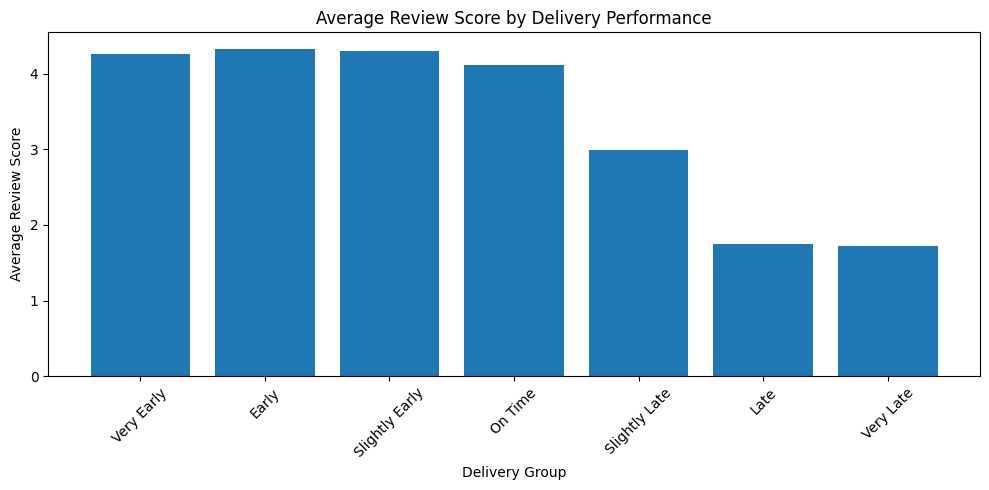

In [75]:
plt.figure(figsize=(10,5))

plt.bar(
    review_delivery_analysis["delivery_group"],
    review_delivery_analysis["review_score"]
)

plt.title("Average Review Score by Delivery Performance")
plt.xlabel("Delivery Group")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
products_en = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_en.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [77]:
category_sales = order_items.merge(
    products_en[[
        "product_id",
        "product_category_name_english"
    ]],
    on="product_id",
    how="left"
)

category_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_item_value,shipping_pct,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,18.409752,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,7.670400,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,8.239959,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,49.612102,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,8.319574,garden_tools


In [78]:
#Revenue by Category
category_revenue = (
    category_sales
    .groupby("product_category_name_english")["total_item_value"]
    .sum()
    .reset_index()
    .sort_values(
        by="total_item_value",
        ascending=False
    )
)

category_revenue.head(10)

,product_category_name_english,total_item_value
43,health_beauty,1441248.07
70,watches_gifts,1305541.61
7,bed_bath_table,1241681.72
65,sports_leisure,1156656.48
15,computers_accessories,1059272.40
39,furniture_decor,902511.79
49,housewares,778397.77
20,cool_stuff,719329.95
5,auto,685384.32
42,garden_tools,584219.21


In [79]:
#Top Categories by Units Sold
category_units = (
    category_sales
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="units_sold")
    .sort_values(
        by="units_sold",
        ascending=False
    )
)

category_units.head(10)

,product_category_name_english,units_sold
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827
49,housewares,6964
70,watches_gifts,5991
68,telephony,4545
42,garden_tools,4347
5,auto,4235


In [80]:
#Average Revenue Per Unit by Category
category_metrics = (
    category_sales
    .groupby("product_category_name_english")
    .agg(
        revenue=("total_item_value", "sum"),
        units_sold=("product_id", "count")
    )
    .reset_index()
)

category_metrics["avg_revenue_per_unit"] = (
    category_metrics["revenue"]
    / category_metrics["units_sold"]
)

category_metrics.sort_values(
    by="avg_revenue_per_unit",
    ascending=False
).head(10)

,product_category_name_english,revenue,units_sold,avg_revenue_per_unit
14,computers,232799.43,203,1146.795222
64,small_appliances_home_oven_and_coffee,50193.57,76,660.441711
45,home_appliances_2,123917.92,238,520.663529
0,agro_industry_and_commerce,78374.07,212,369.689009
56,musical_instruments,210137.37,680,309.025544
63,small_appliances,206668.83,679,304.372356
34,fixed_telephony,64220.81,264,243.260644
19,construction_tools_safety,44463.62,194,229.193918
38,furniture_bedroom,24661.01,109,226.247798
70,watches_gifts,1305541.61,5991,217.917144


In [81]:
#Seller Revenue Analysis
seller_revenue = (
    order_items
    .groupby("seller_id")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique"),
        products_sold=("product_id", "count")
    )
    .reset_index()
)

seller_revenue.head()

,seller_id,revenue,orders,products_sold
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,3
1,001cca7ae9ae17fb1caed9dfb1094831,33934.17,200,239
2,001e6ad469a905060d959994f1b41e4f,267.94,1,1
3,002100f778ceb8431b7a1020ff7ab48f,2028.16,51,55
4,003554e2dce176b5555353e4f3555ac8,139.38,1,1


In [82]:
#Top Sellers by Revenue
seller_revenue.sort_values(
    by="revenue",
    ascending=False
).head(10)

,seller_id,revenue,orders,products_sold
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132,1156
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44,982,1364
1013,53243585a1d6dc2643021fd1853d8905,235856.68,358,410
881,4a3ca9315b744ce9f8e9374361493884,235539.96,1806,1987
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585,586
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1314,1551
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05,336,340
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,915,1428
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38,1160,1171
1824,955fee9216a65b617aa5c0531780ce60,160602.68,1287,1499


In [83]:
seller_revenue["revenue"].describe()

count      3095.000000
mean       5119.080207
std       15922.192727
min          12.220000
25%         269.735000
50%         996.840000
75%        3964.530000
max      249640.700000
Name: revenue, dtype: float64

In [84]:
top_10_revenue = (
    seller_revenue
    .sort_values("revenue", ascending=False)
    .head(10)["revenue"]
    .sum()
)

total_revenue = seller_revenue["revenue"].sum()

(top_10_revenue / total_revenue) * 100

np.float64(12.804682126974695)

In [85]:
# State that generates the most orders
customer_orders = orders.merge(
    customers[[
        "customer_id", 
        "customer_state"
    ]],
    on = "customer_id",
    how = "left"
)

state_orders = (
    customer_orders
    .groupby("customer_state")["order_id"]
    .count()
    .reset_index(name="total_orders")
    .sort_values(
        by="total_orders",
        ascending=False
    )
)

state_orders.head(10)

,customer_state,total_orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [86]:
# States that generates the most revenue
order_revenue = (
    order_items
    .groupby("order_id")["total_item_value"]
    .sum()
    .reset_index()
)

state_revenue = (
    customer_orders
    .merge(order_revenue, on="order_id")
)

state_revenue_analysis = (
    state_revenue
    .groupby("customer_state")["total_item_value"]
    .sum()
    .reset_index()
    .sort_values(
        by="total_item_value",
        ascending=False
    )
)

state_revenue_analysis.head(10)

,customer_state,total_item_value
25,SP,5921678.12
18,RJ,2129681.98
10,MG,1856161.49
22,RS,885826.76
17,PR,800935.44
4,BA,611506.67
23,SC,610213.60
6,DF,353229.44
8,GO,347706.93
7,ES,324801.91


In [87]:
#Revenue Per Order by State
state_metrics = (
    state_revenue
    .groupby("customer_state")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

state_metrics["revenue_per_order"] = (
    state_metrics["revenue"]
    / state_metrics["orders"]
)

state_metrics.sort_values(
    by="revenue_per_order",
    ascending=False
).head(10)

,customer_state,revenue,orders,revenue_per_order
14,PB,140987.81,532,265.014680
0,AC,19669.70,81,242.835802
3,AP,16262.80,68,239.158824
1,AL,96229.40,411,234.134793
20,RO,57558.02,247,233.028421
13,PA,217647.11,970,224.378464
26,TO,61354.42,279,219.908315
16,PI,108132.28,493,219.335254
21,RR,10064.62,46,218.796087
24,SE,73032.32,345,211.687884


In [88]:
state_orders.head(10)

,customer_state,total_orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [89]:
state_revenue_analysis.head(10)

,customer_state,total_item_value
25,SP,5921678.12
18,RJ,2129681.98
10,MG,1856161.49
22,RS,885826.76
17,PR,800935.44
4,BA,611506.67
23,SC,610213.60
6,DF,353229.44
8,GO,347706.93
7,ES,324801.91


In [90]:
state_metrics.sort_values(
    by="revenue_per_order",
    ascending=False
).head(10)

,customer_state,revenue,orders,revenue_per_order
14,PB,140987.81,532,265.014680
0,AC,19669.70,81,242.835802
3,AP,16262.80,68,239.158824
1,AL,96229.40,411,234.134793
20,RO,57558.02,247,233.028421
13,PA,217647.11,970,224.378464
26,TO,61354.42,279,219.908315
16,PI,108132.28,493,219.335254
21,RR,10064.62,46,218.796087
24,SE,73032.32,345,211.687884


In [91]:
#Saving Dashboard Datasets
os.makedirs("data/processed", exist_ok=True)

datasets = {
    "monthly_revenue": monthly_revenue,
    "review_delivery_analysis": review_delivery_analysis,
    "category_revenue": category_revenue,
    "category_units": category_units,
    "category_metrics": category_metrics,
    "seller_revenue": seller_revenue,
    "state_orders": state_orders,
    "state_revenue": state_revenue_analysis,
    "state_metrics": state_metrics
}

for name, df in datasets.items():
    df.to_csv(f"data/processed/{name}.csv", index=False)

print("All datasets saved successfully!")

All datasets saved successfully!


In [92]:
kpi_df = pd.DataFrame({
    "Total Revenue":[order_items["total_item_value"].sum()],
    "Total Orders":[orders["order_id"].nunique()],
    "Total Customers":[customers["customer_unique_id"].nunique()],
    "Average Order Value":[order_revenue["total_item_value"].mean()],
    "Average Delivery Time":[orders["delivery_days"].mean()]
})

kpi_df.to_csv(
    "data/processed/kpi_metrics.csv",
    index=False
)

In [93]:
os.listdir("data/processed")

['category_metrics.csv',
 'category_revenue.csv',
 'category_units.csv',
 'kpi_metrics.csv',
 'monthly_revenue.csv',
 'review_delivery_analysis.csv',
 'seller_revenue.csv',
 'state_metrics.csv',
 'state_orders.csv',
 'state_revenue.csv']

In [94]:
!pip install dash plotly
import dash
import plotly

print(dash.__version__)
print(plotly.__version__)

Defaulting to user installation because normal site-packages is not writeable
4.2.0
6.3.0


In [107]:
def create_card(title, value, subtitle, icon):

    return html.Div(

        [

            html.H4(
                f"{icon} {title}",
                style={
                    "color": "#9CA3AF",
                    "marginBottom": "10px"
                }
            ),

            html.H2(
                value,
                style={
                    "color": "white",
                    "marginBottom": "5px"
                }
            ),

            html.P(
                subtitle,
                style={
                    "color": "#6B7280"
                }
            )

        ],

        style={
            "backgroundColor": "#1F2937",
            "padding": "20px",
            "borderRadius": "15px",
            "width": "18%",
            "textAlign": "center"
        }

    )

In [108]:
#Create the 5 Cards
revenue_card = create_card(
    title="Revenue",
    value="15.84M",
    subtitle="Marketplace Revenue",
    icon="💰"
)

orders_card = create_card(
    title="Orders",
    value="99,441",
    subtitle="Total Orders",
    icon="📦"
)

customers_card = create_card(
    title="Customers",
    value="96,096",
    subtitle="Unique Buyers",
    icon="👥"
)

aov_card = create_card(
    title="AOV",
    value="160.58",
    subtitle="Avg Order Value",
    icon="🛒"
)

delivery_card = create_card(
    title="Delivery",
    value="12.09 Days",
    subtitle="Avg Delivery Time",
    icon="🚚"
)

In [109]:
#Creating KPI row
kpi_row = html.Div(

    [
        revenue_card,
        orders_card,
        customers_card,
        aov_card,
        delivery_card
    ],

    style={
        "display": "flex",
        "justifyContent": "space-between",
        "marginTop": "40px"
    }

)

In [111]:
from dash import Dash, html, dcc
# ==========================
# LOAD DATA
# ==========================

kpi_df = pd.read_csv("data/processed/kpi_metrics.csv")
monthly_revenue = pd.read_csv("data/processed/monthly_revenue.csv")
state_revenue = pd.read_csv("data/processed/state_revenue.csv")

# ==========================
# KPI VALUES
# ==========================

total_revenue = round(kpi_df["Total Revenue"][0], 2)
total_orders = int(kpi_df["Total Orders"][0])
total_customers = int(kpi_df["Total Customers"][0])
aov = round(kpi_df["Average Order Value"][0], 2)
avg_delivery = round(kpi_df["Average Delivery Time"][0], 2)

# ==========================
# KPI CARD FUNCTION
# ==========================

def create_card(title, value, subtitle, icon):

    return html.Div(
        [

            html.H4(
                f"{icon} {title}",
                style={
                    "color": "#9CA3AF"
                }
            ),

            html.H2(
                value,
                style={
                    "color": "white"
                }
            ),

            html.P(
                subtitle,
                style={
                    "color": "#6B7280"
                }
            )

        ],

        style={
            "backgroundColor": "#1F2937",
            "padding": "20px",
            "borderRadius": "15px",
            "width": "18%",
            "textAlign": "center"
        }
    )

# ==========================
# KPI ROW
# ==========================

kpi_row = html.Div(

    [

        create_card(
            "Revenue",
            f"${total_revenue:,.0f}",
            "Marketplace Revenue",
            "💰"
        ),

        create_card(
            "Orders",
            f"{total_orders:,}",
            "Total Orders",
            "📦"
        ),

        create_card(
            "Customers",
            f"{total_customers:,}",
            "Unique Buyers",
            "👥"
        ),

        create_card(
            "AOV",
            f"${aov}",
            "Average Order Value",
            "🛒"
        ),

        create_card(
            "Delivery",
            f"{avg_delivery} Days",
            "Average Delivery Time",
            "🚚"
        )

    ],

    style={
        "display": "flex",
        "justifyContent": "space-between",
        "marginTop": "40px"
    }
)

# ==========================
# CHARTS
# ==========================

fig_monthly = px.line(
    monthly_revenue,
    x="year_month",
    y="total_item_value",
    title="Monthly Revenue Trend"
)

fig_monthly.update_layout(
    paper_bgcolor="#111827",
    plot_bgcolor="#111827",
    font_color="white"
)

fig_state = px.bar(
    state_revenue.head(10),
    x="customer_state",
    y="total_item_value",
    title="Top States by Revenue"
)

fig_state.update_layout(
    paper_bgcolor="#111827",
    plot_bgcolor="#111827",
    font_color="white"
)

# ==========================
# DASH APP
# ==========================

app = Dash(__name__)

app.layout = html.Div(

    style={
        "backgroundColor": "#111827",
        "minHeight": "100vh",
        "padding": "30px",
        "fontFamily": "Arial"
    },

    children=[

        html.H1(
            "Predictive E-Commerce Intelligence Platform",
            style={
                "color": "white",
                "textAlign": "center"
            }
        ),

        html.P(
            "Interactive dashboard for revenue, customer satisfaction, product performance, seller intelligence, and geographic insights.",
            style={
                "color": "#D1D5DB",
                "textAlign": "center",
                "fontSize": "18px"
            }
        ),

        kpi_row,

        html.Br(),

        dcc.Graph(
            figure=fig_monthly
        ),

        dcc.Graph(
            figure=fig_state
        )

    ]
)

if __name__ == "__main__":
    app.run(
        debug=True,
        port=8051
    )

OSError: Address 'http://127.0.0.1:8051' already in use.
    Try passing a different port to run.

# Dashboard Insights

The dashboard provides a comprehensive view of marketplace performance and helps answer key business questions:

* How is revenue changing over time?
* Which product categories generate the highest revenue and sales volume?
* Which categories represent premium, high-value purchases?
* How does delivery performance impact customer satisfaction?
* Which sellers contribute the most revenue to the marketplace?
* Which states generate the highest orders and revenue?
* Which regions have the highest customer spending per order?

The dashboard transforms raw e-commerce data into actionable insights, enabling data-driven decisions across sales, operations, customer experience, and marketplace growth.


In [ ]:
#Customer Satisfaction vs Delivery Performance
fig = px.bar(
    review_delivery_analysis,
    x = "delivery_group",
    y = "review_score",
    color = "review_score",
    text = "review_score",
    title = "Impact of Delivery Performance on Customer Satisfaction",
    color_continuous_scale = "RdYlGn"
)

fig.update_traces(
    texttemplate = "%{text:0.2f}",
    textposition = "outside"
)

fig.update_layout(
    title_x = 0.5,
    xaxis_title = "Delivery Performance",
    yaxis_title = "Average Review Score",
    height = 600,
    coloraxis_showscale = False
)
fig.show()

## Key Findings

- Customers receiving orders early or on time provide ratings above 4 stars.
- Slightly late deliveries reduce ratings to approximately 3 stars.
- Late and very late deliveries result in ratings below 2 stars.
- Delivery performance has a significant impact on customer satisfaction.

## Business Impact

Improving logistics and reducing delivery delays can substantially improve customer experience and review ratings.

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    category_metrics,
    x="units_sold",
    y="revenue",
    z="avg_revenue_per_unit",
    color="revenue",
    size="avg_revenue_per_unit",
    hover_name="product_category_name_english",
    title="Category Intelligence Matrix",
    color_continuous_scale="Turbo"
)

fig.update_layout(
    title_x=0.5,
    height=750,

    paper_bgcolor="#111827",
    font_color="white",

    scene=dict(
        xaxis_title="Units Sold",
        yaxis_title="Revenue",
        zaxis_title="Average Revenue Per Unit",

        bgcolor="#1F2937",

        xaxis=dict(
            backgroundcolor="#1F2937",
            gridcolor="gray",
            color="white"
        ),

        yaxis=dict(
            backgroundcolor="#1F2937",
            gridcolor="gray",
            color="white"
        ),

        zaxis=dict(
            backgroundcolor="#1F2937",
            gridcolor="gray",
            color="white"
        )
    )
)

fig.show()

## Key Findings

- A small number of categories generate the majority of marketplace revenue.
- Several premium categories achieve high revenue per unit despite lower sales volume.
- High-volume categories form the core revenue drivers of the marketplace.
- Many categories belong to the long-tail segment with relatively low contribution.

## Business Impact

The marketplace should continue investing in top-performing categories while developing targeted strategies for premium niche categories.

In [ ]:
top_categories = category_metrics.nlargest(
    10,
    "revenue"
)

In [ ]:
#Premium Category Analysis
fig = px.scatter(
    top_categories,
    x="units_sold",
    y="revenue",
    size="avg_revenue_per_unit",
    color="revenue",
    hover_name="product_category_name_english",
    title="Premium Category Analysis",
    color_continuous_scale="Turbo"
)

fig.update_layout(
    title_x=0.5,
    height=700,
    paper_bgcolor="#111827",
    plot_bgcolor="#1F2937",
    font_color="white"
)

fig.update_xaxes(
    title="Units Sold",
    gridcolor="gray"
)

fig.update_yaxes(
    title="Revenue",
    gridcolor="gray"
)

fig.update_traces(
    textposition = "top center"
)
fig.show()

## Key Findings

- Revenue is not driven solely by sales volume.
- Some categories generate significantly higher revenue per unit than others.
- Premium categories can contribute substantial revenue despite lower transaction volumes.
- High-volume categories and premium categories represent different growth opportunities.

## Business Impact

Pricing and category strategy should be customized based on category positioning rather than relying only on sales volume.

In [ ]:
seller_revenue.head()

In [ ]:
# Seller Performance
fig = px.scatter_3d(
    seller_revenue,
    x="orders",
    y="revenue",
    z="products_sold",
    color="revenue",
    size="revenue",
    hover_name="seller_id",
    title="Seller Performance Universe",
    color_continuous_scale="Turbo"
)

fig.update_layout(
    title_x=0.5,
    height=750,

    paper_bgcolor="#111827",
    font_color="white",

    scene=dict(
        xaxis_title="Orders",
        yaxis_title="Revenue",
        zaxis_title="Products Sold",

        bgcolor="#1F2937",

        xaxis=dict(
            backgroundcolor="#1F2937",
            gridcolor="gray",
            color="white"
        ),

        yaxis=dict(
            backgroundcolor="#1F2937",
            gridcolor="gray",
            color="white"
        ),

        zaxis=dict(
            backgroundcolor="#1F2937",
            gridcolor="gray",
            color="white"
        )
    )
)

fig.show()

## Key Findings

- Seller performance follows a highly concentrated distribution, with a small group of sellers generating a substantial portion of marketplace revenue.
- Most sellers belong to the long-tail segment, contributing relatively low revenue and order volume.
- A strong positive relationship exists between orders, products sold, and revenue generation.
- Several sellers appear to operate in premium segments, generating higher revenue despite comparatively lower order volumes.

## Business Impact

- Marketplace growth is highly dependent on retaining top-performing sellers.
- Long-tail sellers represent an opportunity for seller development and performance improvement programs.
- Premium sellers should be identified and supported through targeted incentives and partnership strategies.
- Seller segmentation can help optimize marketplace growth and resource allocation.

In [ ]:
#Revenue by State 
fig = px.bar(
    state_revenue.head(10),
    x="customer_state",
    y="total_item_value",
    color="total_item_value",
    text="total_item_value",
    title="Top 10 States by Revenue",
    color_continuous_scale="Turbo"
)

fig.update_traces(
    texttemplate="%{text:.0f}",
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    height=650,
    paper_bgcolor="#111827",
    plot_bgcolor="#1F2937",
    font_color="white",
    coloraxis_showscale=False
)

fig.update_xaxes(gridcolor="gray")
fig.update_yaxes(gridcolor="gray")

fig.show()

## Key Findings

### Revenue Distribution

- São Paulo (SP) is the dominant market, generating approximately 5.92M in revenue.
- SP generates nearly three times more revenue than the second-ranked state (RJ).
- Revenue is highly concentrated among a small number of states.
- RJ and MG form the second tier of major revenue-generating regions.

In [ ]:
#Orders by State
fig = px.bar(
    state_orders.head(10),
    x="customer_state",
    y="total_orders",
    color="total_orders",
    text="total_orders",
    title="Top 10 States by Orders",
    color_continuous_scale="Turbo"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    height=650,
    paper_bgcolor="#111827",
    plot_bgcolor="#1F2937",
    font_color="white",
    coloraxis_showscale=False
)

fig.show()

### Order Volume Analysis

- SP leads with more than 41,000 orders, significantly exceeding all other states.
- The ranking of states by orders closely matches the ranking by revenue.
- This indicates that revenue growth is primarily driven by transaction volume rather than unusually high spending.

In [ ]:
#Revenue per Order by State
fig = px.bar(
    state_metrics.sort_values(
        "revenue_per_order",
        ascending=False
    ).head(10),
    x="customer_state",
    y="revenue_per_order",
    color="revenue_per_order",
    text="revenue_per_order",
    title="Top States by Revenue Per Order",
    color_continuous_scale="Turbo"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    height=650,
    paper_bgcolor="#111827",
    plot_bgcolor="#1F2937",
    font_color="white",
    coloraxis_showscale=False
)

fig.show()

### Revenue Per Order Analysis

- PB, AC, and AP have the highest revenue per order despite not appearing among the top states by total revenue.
- High revenue per order does not necessarily translate into high overall marketplace revenue.
- Some smaller states exhibit premium purchasing behavior with higher average spending per transaction.

## Business Impact

- São Paulo should remain the primary target for customer acquisition and retention strategies.
- RJ and MG represent important secondary markets with strong revenue potential.
- States with high revenue per order may be suitable targets for premium product campaigns.
- Geographic segmentation can improve marketing efficiency by tailoring strategies to regional purchasing behavior.

In [ ]:
corr_matrix = review_delivery_df[
    [
        "delivery_days",
        "delivery_delay_days",
        "review_score"
    ]
].corr()

corr_matrix

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title(
    "Customer Experience Correlation Heatmap"
)

plt.tight_layout()

plt.show()

## Key Findings

- Customer review scores decrease as delivery delays increase.
- Delivery time and delivery delay exhibit a positive relationship.
- Delivery performance is one of the strongest drivers of customer satisfaction.
- Customers are highly sensitive to late deliveries.

## Business Impact

- Reducing delivery delays can directly improve customer satisfaction.
- Logistics performance should be treated as a key business metric.
- Investments in fulfillment and delivery optimization may yield significant customer experience improvements.

In [ ]:
monthly_revenue_clean = monthly_revenue[
    monthly_revenue["total_item_value"] > 10000
].copy()

monthly_revenue_clean

In [ ]:
monthly_revenue_clean["moving_avg_3"] = (
    monthly_revenue_clean["total_item_value"]
    .rolling(3)
    .mean()
)

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_revenue_clean["year_month"].astype(str),
        y=monthly_revenue_clean["total_item_value"],
        mode="lines+markers",
        name="Monthly Revenue"
    )
)

fig.add_trace(
    go.Scatter(
        x=monthly_revenue_clean["year_month"].astype(str),
        y=monthly_revenue_clean["moving_avg_3"],
        mode="lines",
        name="3-Month Moving Average"
    )
)

fig.update_layout(
    title="Revenue Trend and Moving Average",
    title_x=0.5,
    height=650,
    paper_bgcolor="#111827",
    plot_bgcolor="#1F2937",
    font_color="white"
)

fig.show()

## Key Findings

- Marketplace revenue experienced significant growth between 2017 and 2018.
- The 3-month moving average confirms a strong long-term upward trend.
- Revenue growth accelerated during late 2017, indicating rapid marketplace expansion.
- During 2018, revenue stabilized around the 1M mark, suggesting a transition toward a more mature growth stage.

## Business Impact

- The marketplace demonstrated successful customer and seller acquisition during the observation period.
- Sustaining future growth may require expansion into new markets, categories, or customer segments.
- Revenue stability indicates a healthy and established marketplace foundation.

In [ ]:
monthly_revenue_clean = monthly_revenue_clean.reset_index(drop=True)

monthly_revenue_clean["month_index"] = range(
    len(monthly_revenue_clean)
)

In [ ]:
#Train Linear Regression Model
from sklearn.linear_model import LinearRegression

X = monthly_revenue_clean[["month_index"]]
y = monthly_revenue_clean["total_item_value"]

model = LinearRegression()

model.fit(X, y)

monthly_revenue_clean["predicted_revenue"] = model.predict(X)

In [ ]:
future_months = pd.DataFrame(
    {
        "month_index": range(
            len(monthly_revenue_clean),
            len(monthly_revenue_clean) + 6
        )
    }
)

future_months["forecast_revenue"] = (
    model.predict(future_months)
)

future_months

In [ ]:
fig = go.Figure()

# Actual Revenue
fig.add_trace(
    go.Scatter(
        x=monthly_revenue_clean["year_month"].astype(str),
        y=monthly_revenue_clean["total_item_value"],
        mode="lines+markers",
        name="Actual Revenue"
    )
)

# Regression Trend
fig.add_trace(
    go.Scatter(
        x=monthly_revenue_clean["year_month"].astype(str),
        y=monthly_revenue_clean["predicted_revenue"],
        mode="lines",
        name="Regression Trend"
    )
)

fig.update_layout(
    title="Revenue Trend Forecast Using Linear Regression",
    title_x=0.5,
    height=650,
    paper_bgcolor="#111827",
    plot_bgcolor="#1F2937",
    font_color="white"
)

fig.show()

## Key Findings

- Linear Regression indicates a positive long-term revenue trend.
- Forecasted revenue continues to grow over future periods.
- Historical growth patterns suggest sustained marketplace expansion.
- The predictive model estimates continued revenue growth beyond the observed period.

## Business Impact

- Future revenue is expected to remain strong based on historical trends.
- Growth initiatives should continue to capitalize on the positive trajectory.
- Revenue forecasting can support strategic planning, budgeting, and resource allocation.

In [ ]:
future_months

## Predictive Analytics Findings

### Revenue Forecast

- A Linear Regression model was trained using monthly revenue data.
- The model identified a positive long-term relationship between time and revenue.
- Forecasted revenue is expected to increase from approximately 1.33M to 1.59M over the next six periods.
- The projected trend indicates continued marketplace growth.

### Business Impact

- Revenue growth is expected to remain positive if historical trends continue.
- Forecasting can support budgeting, capacity planning, and strategic decision-making.
- Continued investment in customer acquisition and seller expansion may further accelerate growth.
- Future models can be enhanced with seasonality and promotional factors for improved accuracy.